# **Programa Especializado en Credit Scoring con Python**
<img src="../../figuras/logo.png" width="200"/>

## 📊 **Sesión 9: Credit Scoring Tradicional vs Machine Learning..**

**Docente**: Enzo Infantes Zúñiga  
**Contacto**: <enzo.infantes28@gmail.com>  
**LinkedIn**: [enzo-infantes](https://www.linkedin.com/in/enzo-infantes/)

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
import warnings

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve
from sklearn.metrics import average_precision_score, brier_score_loss

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)

warnings.filterwarnings("ignore")

np.random.seed(42)

absolute_path = os.path.dirname(os.path.dirname(os.getcwd()))
data_path = os.path.join(absolute_path, "data", "s08")
src_path = os.path.join(absolute_path, "src", "s08")
model_path = os.path.join(absolute_path, "models", "s08")
figure_path = os.path.join(absolute_path, "figuras", "s08")
sys.path.insert(0, src_path)

PALETTE = ['#2C5F8A', '#E8523A', '#2CA02C', '#FF7F0E', '#9467BD', '#8C564B']
sns.set_palette(PALETTE)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

## 🎯 **Objetivos de la sesión**

Al finalizar esta sesión, el participante será capaz de:

1. Reconocer las **limitaciones técnicas y regulatorias** de los modelos tradicionales de scoring.
2. Identificar y clasificar los principales **algoritmos de Machine Learning** aplicables al crédito.
3. Comparar ambos enfoques en dimensiones de **rendimiento, interpretabilidad y gobernanza**.
4. Ejecutar un **benchmark empírico** sobre un dataset de crédito real.
5. Articular un **framework de decisión** para seleccionar el enfoque adecuado según el contexto instituciona


# 🔁 **1. Recapitulación y Motivación**

## **1.1 ¿Qué construimos en el Curso I?**

En las primeras ocho sesiones construimos el **pipeline clásico de credit scoring** basado en regresión logística:

```
Datos Brutos
    ↓
Definición del Evento de Incumplimiento (Sesión 2)
    ↓
EDA + Tratamiento de variables (Sesión 3)
    ↓
WOE / IV (Sesión 4)
    ↓
Regresión Logística (Sesión 5)
    ↓
Evaluación: Gini, KS, AUC (Sesión 6)
    ↓
Validación + PSI/CSI (Sesión 7)
    ↓
Scorecard + Puntos de corte (Sesión 8)
```

Este pipeline es **sólido, regulatoriamente aceptado y ampliamente utilizado** en la banca tradicional. Pero tiene limitaciones que exploraremos en esta sesión.

## **1.2 ¿Por qué transicionar hacia Machine Learning?**

Cuatro fuerzas impulsoras del cambio en la industria financiera:

| Fuerza | Descripción |
|--------|-------------|
| 📊 **Volumen y variedad de datos** | Datos alternativos (transaccionales, de comportamiento) que la regresión logística no aprovecha bien |
| ⚡ **Poder computacional** | La nube y los GPUs hacen entrenable en minutos modelos que antes tardaban días |
| 🎯 **Presión por performance** | Mercados competitivos exigen discriminación predictiva más fina |
| 🏛️ **Evolución regulatoria** | IFRS 9, Basilea IV y las guidelines de la EBA permiten (con condiciones) modelos no lineales |


**Advertencia temprana:** ML no es sinónimo de "mejor". En muchos contextos bancarios regulados, una regresión logística bien calibrada supera a un modelo complejo mal gobernado.

<img src="../../figuras/s09/sesion09_benchmark_auc_overview.png" width="1200"/>

# 🗺️ **2. Panorama del Ecosistema ML en Credit Scoring**

## **2.1 Taxonomía de Algoritmos para Clasificación Binaria**

Los modelos que usaremos en el Curso II se organizan en tres familias:

### **Familia 1: Modelos Basados en Árboles**
| Algoritmo | Tipo | Sesión | Complejidad |
|-----------|------|--------|-------------|
| Decision Tree | Árbol único | 11 | Baja |
| Random Forest | Ensemble bagging | 11 | Media |
| Gradient Boosting | Ensemble boosting | 12 | Alta |
| XGBoost | Boosting optimizado | 12 | Alta |
| LightGBM | Boosting ultra-eficiente | 12 | Alta |

### **Familia 2: Modelos Lineales Extendidos**
| Algoritmo | Tipo | Uso en Credit |
|-----------|------|---------------|
| Regresión Logística | Lineal | Baseline + scorecard |
| Logística Regularizada (L1/L2) | Lineal + penalización | Selección de variables |
| Elastic Net | Lineal + penalización mixta | Alta dimensionalidad |

También, existe una familia de modelos con algoritmos avanzandos de aprendizaje:
### **Familia 3: Modelos No Paramétricos Avanzados**
| Algoritmo | Característica | Limitación en Credit |
|-----------|----------------|----------------------|
| SVM | Buen discriminador en fronteras complejas | Difícil interpretación |
| KNN | Simple y local | No escala bien |
| Redes Neuronales | Altísima capacidad | Caja negra, regulatorio complejo |

## **2.2 Posición en el Ciclo de Crédito**

Los modelos de scoring se usan en distintos momentos del ciclo crediticio, y el enfoque óptimo varía:

| Etapa | Modelo Típico | ¿ML Agrega Valor? |
|-------|--------------|-------------------|
| **Originación** (application scoring) | Logística + WOE | Alto, especialmente con datos alternativos |
| **Comportamiento** (behavioral scoring) | Logística o RF | Muy alto (datos transaccionales) |
| **Cobranza** (collection scoring) | Logística | Medio-alto |
| **Fraude** | Ensemble / NN | Muy alto |
| **IFRS 9 PD** | Logística / RF | Medio (requiere interpretabilidad) |

A continuación, se muestra un mapa de modelos que relaciona interpretabilidad y capacidad predictiva:

<img src="../../figuras/s09/sesion09_mapa_modelos.png" width="1200"/>

# 📐 **3. Regresión Logística: Revisión Crítica**

## **3.1 El Modelo que Domina (o dominó) la Industria**

La regresión logística es, con diferencia, el modelo más utilizado en credit scoring institucional. Para entender por qué ML puede agregarle valor, primero debemos entender **profundamente** sus supuestos y limitaciones.

**Formulación del Modelo**

$$P(Y=1 \mid X) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 X_1 + \cdots + \beta_p X_p)}}$$

donde $Y=1$ indica incumplimiento (default).

**Supuestos Críticos**

| Supuesto | Descripción | ¿Se cumple en crédito? |
|----------|-------------|------------------------|
| **Linealidad en log-odds** | La relación $X_i \rightarrow \text{logit}(P)$ es lineal | Frecuentemente **no** (por eso usamos WOE) |
| **Independencia de observaciones** | Las observaciones son i.i.d. | Parcialmente (correlación temporal) |
| **Ausencia de multicolinealidad** | Las variables predictoras no están correladas | Problemático con buro data |
| **Sin valores extremos influyentes** | Outliers no distorsionan los parámetros | Relevante en variables monetarias |
| **Muestra suficiente** | Regla heurística: ≥10 eventos por variable | A veces violado en productos nicho |

## 3.2 Fortalezas que ML No Siempre Supera
✅ Coeficientes directamente interpretables como odds ratios \
✅ Produce probabilidades calibradas de forma nativa \
✅ Robusto ante overfitting si se construye con parsimonia \
✅ Fácil de auditar y defender ante reguladores \
✅ Estabilidad: el modelo "envejece" de forma predecible \
✅ Bajo costo computacional de inferencia (producción) \


## 3.3 Limitaciones Reales
❌ No captura interacciones automáticamente \
❌ No maneja bien relaciones no lineales (sin transformaciones manuales) \
❌ Desaprovecha datos de alta dimensionalidad (hundreds of features) \
❌ Requiere ingeniería de variables intensiva (WOE, binning manual) \
❌ Menor capacidad discriminante en presencia de patrones complejos 

Tasa de default: 29.0%  |  n=3000


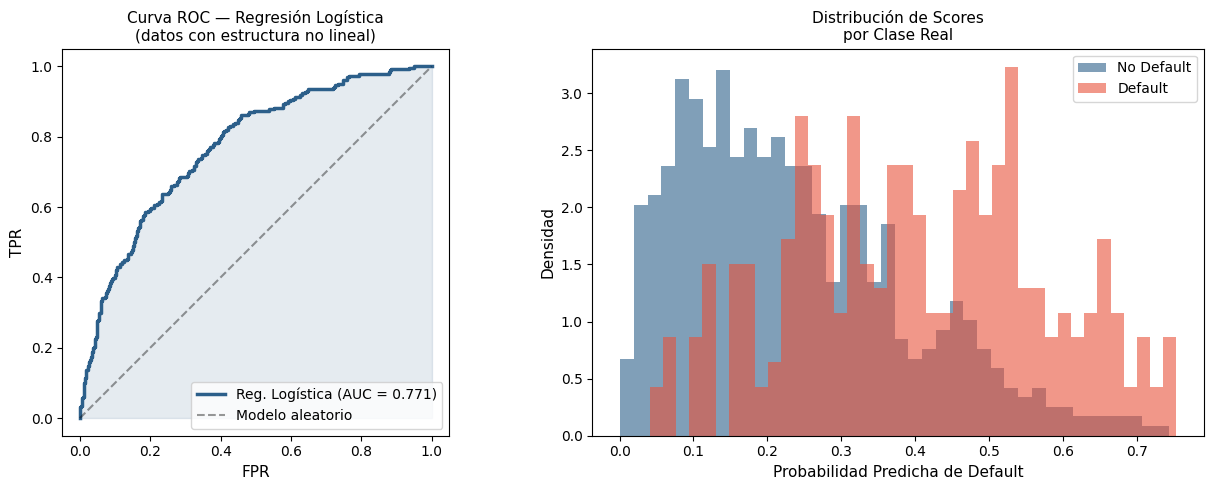


📊 Resultado — Regresión Logística sobre datos no lineales:
   AUC = 0.771  |  Gini = 0.543

💡 Interpretación:
   • La RL asume relaciones lineales entre variables y log-odds.
   • No puede capturar el riesgo en forma de U (edad) ni umbrales (deuda).
   • Esto motiva el uso de modelos ML más flexibles en las sesiones siguientes.


In [16]:
np.random.seed(42)
n = 3000

# --- Datos sintéticos con estructura no lineal clara ---
# 1. Simulamos un score crediticio donde el riesgo tiene forma de U en edad
# 2. No Linealidad debido a un salto brusco en el ratio de deuda

edad     = np.random.uniform(18, 70, n)
ingresos = np.random.exponential(3000, n) + 500
deuda    = np.random.uniform(0, 1, n)

# Probabilidad de default: parabólica en edad + umbral duro en deuda
# La RL nunca podrá modelar el (edad-40)^2 ni el salto en deuda > 0.6
log_odds_true = (
    - 2.5 * ((edad - 40) / 25) ** 2   # riesgo alto en jóvenes y mayores | Qué tan lejos estás de 40 en unidades de ~25 años
    + 2.0 * (deuda > 0.6).astype(float)  # salto duro en ratio deuda
    - 0.0003 * ingresos
)

prob_true = 1 / (1 + np.exp(-log_odds_true))
y = (np.random.uniform(0, 1, n) < prob_true).astype(int)

print(f"Tasa de default: {y.mean():.1%}  |  n={n}")

X = pd.DataFrame({'edad': edad, 
                  'ingresos': ingresos, 
                  'ratio_deuda': deuda})

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# --- Regresión Logística (solo features lineales, sin transformaciones) ---
rl = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, random_state=42))])

rl.fit(X_tr, y_tr)
prob_rl = rl.predict_proba(X_te)[:, 1]
auc_rl  = roc_auc_score(y_te, prob_rl)

# --- Visualización ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Fig1. Curva ROC
fpr, tpr, _ = roc_curve(y_te, prob_rl)
ax = axes[0]
ax.plot(fpr, tpr, color=PALETTE[0], lw=2.5, label=f'Reg. Logística (AUC = {auc_rl:.3f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, lw=1.5, label='Modelo aleatorio')
ax.fill_between(fpr, tpr, alpha=0.12, color=PALETTE[0])
ax.set_xlabel('FPR', fontsize=11)
ax.set_ylabel('TPR', fontsize=11)
ax.set_title('Curva ROC — Regresión Logística\n(datos con estructura no lineal)', fontsize=11)
ax.legend(fontsize=10, loc='lower right')
ax.set_aspect('equal')

# Fig2. Distribución de scores por clase
ax = axes[1]
ax.hist(prob_rl[y_te == 0], bins=40, alpha=0.6, color=PALETTE[0], density=True, label='No Default')
ax.hist(prob_rl[y_te == 1], bins=40, alpha=0.6, color=PALETTE[1], density=True, label='Default')
ax.set_xlabel('Probabilidad Predicha de Default', fontsize=11)
ax.set_ylabel('Densidad', fontsize=11)
ax.set_title('Distribución de Scores\npor Clase Real', fontsize=11)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('../../figuras/s09/sesion09_limitacion_rl.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📊 Resultado — Regresión Logística sobre datos no lineales:")
print(f"   AUC = {auc_rl:.3f}  |  Gini = {2*auc_rl - 1:.3f}")
print()
print("💡 Interpretación:")
print("   • La RL asume relaciones lineales entre variables y log-odds.")
print("   • No puede capturar el riesgo en forma de U (edad) ni umbrales (deuda).")
print("   • Esto motiva el uso de modelos ML más flexibles en las sesiones siguientes.")

# ⚖️ **4. Comparativa Conceptual**

## **4.1 Las Siete Dimensiones de Evaluación**
Para una comparación justa y útil para la banca, debemos evaluar los modelos en siete dimensiones que los comités de riesgo y los reguladores consideran relevantes:

1. Poder Discriminante        → ¿Qué tan bien separa buenos de malos?
2. Calibración                → ¿Las probabilidades predichas son confiables?
3. Interpretabilidad          → ¿Podemos explicar cada predicción?
4. Estabilidad                → ¿El modelo se degrada lentamente?
5. Requerimientos de Datos    → ¿Cuántos datos necesita para funcionar bien?
6. Costo de Implementación    → ¿Qué tan fácil es poner en producción?
7. Cumplimiento Regulatorio   → ¿Lo acepta el regulador?

## **4.2 Tabla Comparativa Detallada**

| Dimensión | Regresión Logística | Random Forest | Gradient Boosting |
|-----------|--------------------|--------------|-----------------|
| **Discriminación** | ⭐⭐⭐ | ⭐⭐⭐⭐ | ⭐⭐⭐⭐⭐ |
| **Calibración nativa** | ⭐⭐⭐⭐⭐ | ⭐⭐⭐ | ⭐⭐⭐ |
| **Interpretabilidad global** | ⭐⭐⭐⭐⭐ | ⭐⭐⭐ | ⭐⭐ |
| **Interpretabilidad local** | ⭐⭐⭐⭐⭐ | ⭐⭐ (con SHAP) | ⭐⭐ (con SHAP) |
| **Estabilidad temporal** | ⭐⭐⭐⭐ | ⭐⭐⭐⭐ | ⭐⭐⭐ |
| **Muestra pequeña** | ⭐⭐⭐⭐⭐ | ⭐⭐⭐ | ⭐⭐ |
| **Alta dimensionalidad** | ⭐⭐ | ⭐⭐⭐⭐ | ⭐⭐⭐⭐⭐ |
| **Facilidad de auditoría** | ⭐⭐⭐⭐⭐ | ⭐⭐⭐ | ⭐⭐ |
| **Aceptación regulatoria** | ⭐⭐⭐⭐⭐ | ⭐⭐⭐⭐ | ⭐⭐⭐ |

*Escala: ⭐ = Deficiente, ⭐⭐⭐⭐⭐ = Excelente*

## **4.3 El Trade-Off Interpretabilidad-Performance**

Este es el **trade-off central** de la sesión:

> **A mayor complejidad del modelo → Mayor capacidad de capturar patrones → Menor interpretabilidad directa**

<img src="../../figuras/s09/sesion09_radar_comparativa.png" width="700"/>

# 🔬 **5. Benchmarking Empírico**

## **5.1 Modelo de Machine Learning**

Para tener una comparación rápida del performance de los modelos se ha elegido un modelo de `Decision Tree` para este ejercicio.

La idea central de este comparación es ver como un modelo de ML puede:
- Captura no linealidad
- Fácil de interpretar
- No escalamiento de variables

      Métrica  Reg. Logística  Árbol de Decisión
      AUC-ROC        0.771452           0.801720
         Gini        0.542904           0.603439
Avg Precision        0.573767           0.605686


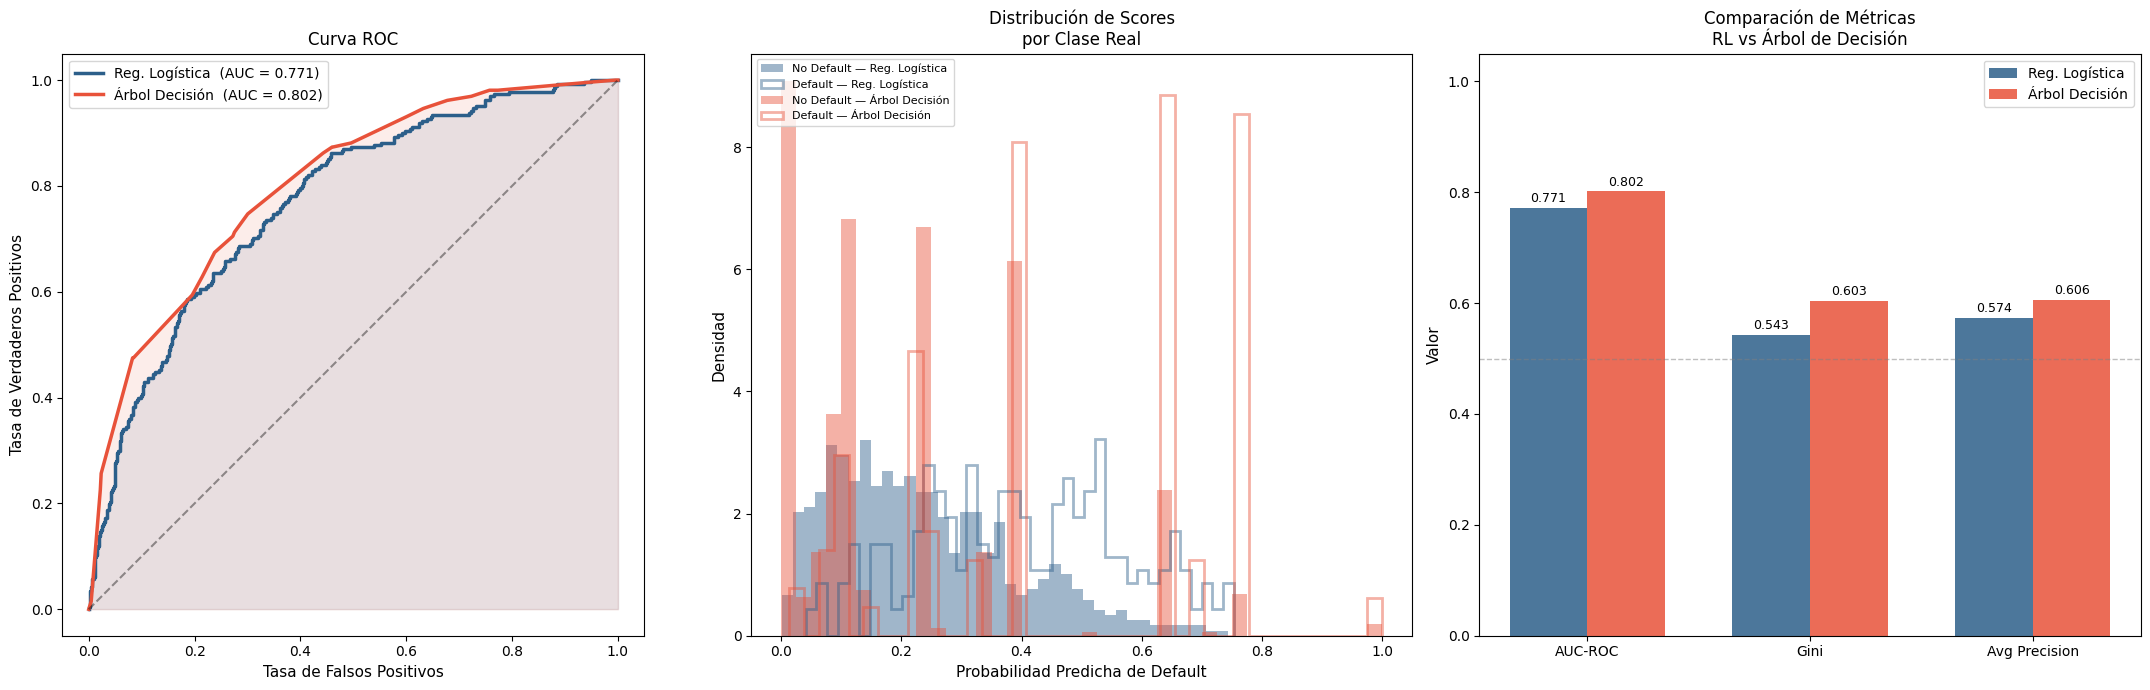


📊 Resumen comparativo:
   AUC   → RL: 0.771  |  DT: 0.802  |  Δ = +0.030 (3.0 pts)
   Gini  → RL: 0.543  |  DT: 0.603  |  Δ = +0.061

💡 Conclusión pedagógica:
   • El árbol captura la parábola en edad y el umbral en ratio_deuda.
   • La RL solo ajusta una frontera lineal → scores comprimidos, AUC menor.
   • Esta brecha justifica explorar modelos ML en las sesiones siguientes.


In [29]:
# --- Árbol de Decisión ---
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_tr, y_tr)
prob_dt = dt.predict_proba(X_te)[:, 1]
auc_dt  = roc_auc_score(y_te, prob_dt)

metrics = {
    'Métrica'             : ['AUC-ROC', 'Gini', 'Avg Precision'],
    'Reg. Logística'      : [
        auc_rl,
        2 * auc_rl - 1,
        average_precision_score(y_te, prob_rl)
    ],
    'Árbol de Decisión'   : [
        auc_dt,
        2 * auc_dt - 1,
        average_precision_score(y_te, prob_dt)
    ],
}

df_metrics = pd.DataFrame(metrics)
print(df_metrics.to_string(index=False))

# --- Visualización ---
fpr_rl, tpr_rl, _ = roc_curve(y_te, prob_rl)
fpr_dt, tpr_dt, _ = roc_curve(y_te, prob_dt)

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# ── Fig 1. Curvas ROC ──────────────────────────────────────────────────
ax = axes[0]
ax.plot(fpr_rl, tpr_rl, color=PALETTE[0], lw=2.5,
        label=f'Reg. Logística  (AUC = {auc_rl:.3f})')
ax.plot(fpr_dt, tpr_dt, color=PALETTE[1], lw=2.5,
        label=f'Árbol Decisión  (AUC = {auc_dt:.3f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, lw=1.5)
ax.fill_between(fpr_rl, tpr_rl, alpha=0.10, color=PALETTE[0])
ax.fill_between(fpr_dt, tpr_dt, alpha=0.10, color=PALETTE[1])
ax.set_xlabel('Tasa de Falsos Positivos', fontsize=11)
ax.set_ylabel('Tasa de Verdaderos Positivos', fontsize=11)
ax.set_title('Curva ROC', fontsize=12)
ax.legend(fontsize=10)
ax.set_aspect('equal')

# ── Fig 2. Distribución de scores por clase ────────────────────────────
ax = axes[1]
for prob, label, color in [
    (prob_rl, 'Reg. Logística', PALETTE[0]),
    (prob_dt, 'Árbol Decisión', PALETTE[1]),
]:
    ax.hist(prob[y_te == 0], bins=40, alpha=0.45, color=color,
            density=True, label=f'No Default — {label}')
    ax.hist(prob[y_te == 1], bins=40, alpha=0.45, color=color,
            density=True, histtype='step', linewidth=2,
            label=f'Default — {label}')
ax.set_xlabel('Probabilidad Predicha de Default', fontsize=11)
ax.set_ylabel('Densidad', fontsize=11)
ax.set_title('Distribución de Scores\npor Clase Real', fontsize=12)
ax.legend(fontsize=8)

# ── Fig 3. Barras comparativas de métricas clave ──────────────────────
ax = axes[2]
metricas_plot = ['AUC-ROC', 'Gini', 'Avg Precision']
vals_rl = df_metrics[df_metrics['Métrica'].isin(metricas_plot)]['Reg. Logística'].values
vals_dt = df_metrics[df_metrics['Métrica'].isin(metricas_plot)]['Árbol de Decisión'].values

x = np.arange(len(metricas_plot))
width = 0.35
bars_rl = ax.bar(x - width/2, vals_rl, width, color=PALETTE[0],
                 alpha=0.85, label='Reg. Logística')
bars_dt = ax.bar(x + width/2, vals_dt, width, color=PALETTE[1],
                 alpha=0.85, label='Árbol Decisión')

for bar in bars_rl:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars_dt:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(metricas_plot, fontsize=10)
ax.set_ylabel('Valor', fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_title('Comparación de Métricas\nRL vs Árbol de Decisión', fontsize=12)
ax.legend(fontsize=10)
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5, linewidth=1)

plt.tight_layout()
plt.savefig('../../figuras/s09/sesion09_rl_vs_dt.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📊 Resumen comparativo:")
print(f"   AUC   → RL: {auc_rl:.3f}  |  DT: {auc_dt:.3f}  |  Δ = +{(auc_dt - auc_rl):.3f} ({(auc_dt - auc_rl)*100:.1f} pts)")
print(f"   Gini  → RL: {2*auc_rl-1:.3f}  |  DT: {2*auc_dt-1:.3f}  |  Δ = +{(auc_dt - auc_rl)*2:.3f}")
print()
print("💡 Conclusión pedagógica:")
print("   • El árbol captura la parábola en edad y el umbral en ratio_deuda.")
print("   • La RL solo ajusta una frontera lineal → scores comprimidos, AUC menor.")
print("   • Esta brecha justifica explorar modelos ML en las sesiones siguientes.")

🏛️  **6. Aspectos Regulatorios**

## **6.1 El Marco Regulatorio Global**

El uso de Machine Learning en credit scoring está cada vez más regulado. Conocer el marco es **indispensable** para cualquier profesional del sector:

**Regulación Clave**

| Marco | Jurisdicción | Impacto en ML Credit Scoring |
|-------|-------------|------------------------------|
| **IRB** | Europa | Exige que los modelos PD sean interpretables y auditables |
| **Basilea IV** | Global | Restricciones a modelos internos (IMM); mayor escrutinio de inputs |
| **IFRS 9** | Global | Requiere trazabilidad de PD en provisiones |

Asimismo, la Reserva Federal (2011) en la guía **SR 11-7** (estándar de Oro del MRM), documento referenciado internacionalmente para la gestión del riesgo de modelos, define el **riesgo de modelo** como *"el riesgo de consecuencias adversas derivadas de decisiones basadas en resultados de modelos incorrectos o mal usados."*

Para modelos ML, los tres pilares son:

```
┌──────────────────────────────────────────────────────────┐
│               SR 11-7 — Tres Pilares                     │
├────────────────┬────────────────┬────────────────────────┤
│  DESARROLLO    │  VALIDACIÓN    │  GOBERNANZA            │
│                │  INDEPENDIENTE │                        │
│ • Documenta-   │ • Back-testing │ • Políticas de uso     │
│   ción técnica │ • Stress-tests │ • Revisión periódica   │
│ • Justifica-   │ • Benchmarking │ • Inventory de modelos │
│   ción teórica │ • Sensibilidad │ • Gestión del ciclo    │
│ • Supuestos    │                │   de vida              │
└────────────────┴────────────────┴────────────────────────┘
```

## **6.2 El Problema del Sesgo Algorítmico**

Los modelos ML pueden **amplificar sesgos históricos** presentes en los datos de entrenamiento. Esto es una preocupación regulatoria creciente, ejemplo conceptual de fuente de sesgo en credit scoring:
- Si históricamente ciertos grupos demográficos tuvieron menos acceso al crédito, los datos de entrenamiento estarán sesgados en esa dirección.
- Un modelo ML que aprende de estos datos perpetuará, o ampliará, la inequidad.